# 05 - Machine Learning Price Prediction

This notebook builds machine learning models to predict Airbnb listing prices in Amsterdam.

The goal is to use cleaned listing, host, property, review, availability, and neighbourhood features to estimate listing-level price.

This is a supervised regression problem because the target variable, price_numeric, is continuous.

Important: estimated_revenue_proxy is excluded from model features because it is calculated using price and would create target leakage.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Base libraries imported successfully.")

Base libraries imported successfully.


In [ ]:
%pip install scikit-learn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


In [3]:
PROJECT_ROOT = Path("..")

WAREHOUSE_PATH = PROJECT_ROOT / "warehouse"
DUCKDB_DATABASE_PATH = WAREHOUSE_PATH / "airbnb_market.duckdb"

ML_REPORTS_PATH = PROJECT_ROOT / "reports" / "machine_learning"
ML_REPORTS_PATH.mkdir(parents=True, exist_ok=True)

ML_FIGURES_PATH = PROJECT_ROOT / "reports" / "figures" / "machine_learning"
ML_FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("DuckDB database exists:", DUCKDB_DATABASE_PATH.exists())
print("ML reports path:", ML_REPORTS_PATH)
print("ML figures path:", ML_FIGURES_PATH)

DuckDB database exists: True
ML reports path: ..\reports\machine_learning
ML figures path: ..\reports\figures\machine_learning


In [4]:
conn = duckdb.connect(
    database=str(DUCKDB_DATABASE_PATH),
    read_only=True
)

listing_master_df = conn.execute("""
SELECT *
FROM listing_master_final
""").fetchdf()

print("listing_master_df shape:", listing_master_df.shape)
listing_master_df.head()

listing_master_df shape: (10465, 101)


,listing_id,listing_name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,...,neighbourhood_min_price,neighbourhood_max_price,neighbourhood_avg_availability_rate,neighbourhood_avg_occupancy_proxy,neighbourhood_avg_review_score,neighbourhood_total_reviews,neighbourhood_avg_reviews_per_listing,neighbourhood_total_revenue_proxy,neighbourhood_avg_revenue_proxy,neighbourhood_dominant_room_type
0,28871,Comfortable double room,124245,1462510208428038912,Edwin,<NA>,Centrum-West,52.367750,4.89092,Private room,...,39.0,11412.0,0.34,0.66,4.82,116784,95.96,65092219.0,74221.46,Entire home/apt
1,29051,Comfortable single / double room,124245,1462510208428038912,Edwin,<NA>,Centrum-Oost,52.365840,4.89111,Private room,...,39.0,2477.0,0.36,0.64,4.81,85025,91.13,44237061.0,65246.40,Entire home/apt
2,44129,Luxury design with canal view,187728,1462512125293144576,Tanya,<NA>,Centrum-West,52.382110,4.88630,Entire home/apt,...,39.0,11412.0,0.34,0.66,4.82,116784,95.96,65092219.0,74221.46,Entire home/apt
3,44391,Quiet 2-bedroom Amsterdam city centre apartment,194779,1462512336903650304,Jan,<NA>,Centrum-Oost,52.371680,4.91471,Entire home/apt,...,39.0,2477.0,0.36,0.64,4.81,85025,91.13,44237061.0,65246.40,Entire home/apt
4,48373,Cozy family home in Amsterdam South,220434,1462513002935125760,Vesna & Misha,<NA>,Buitenveldert - Zuidas,52.327808,4.87680,Entire home/apt,...,40.0,1461.0,0.38,0.62,4.78,4212,35.39,4754582.0,54650.37,Entire home/apt


## 1. Machine Learning Dataset Preparation

This section prepares the dataset for price prediction.

Only listings with valid positive price values are used for supervised learning.  
Rows with missing or invalid price are excluded because the model needs a known target value during training.

In [5]:
ml_df = listing_master_df[
    listing_master_df["price_numeric"].notna() &
    (listing_master_df["price_numeric"] > 0)
].copy()

print("Total listings:", len(listing_master_df))
print("Listings available for ML price prediction:", len(ml_df))
print("Excluded rows with missing/invalid price:", len(listing_master_df) - len(ml_df))

Total listings: 10465
Listings available for ML price prediction: 6471
Excluded rows with missing/invalid price: 3994


In [6]:
target_column = "price_numeric"

y = ml_df[target_column].copy()

print("Target variable:", target_column)
print("Target row count:", len(y))
print("Target missing values:", y.isna().sum())

Target variable: price_numeric
Target row count: 6471
Target missing values: 0


In [7]:
candidate_numeric_features = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "availability_rate",
    "occupancy_proxy",
    "weekend_availability_rate",
    "weekday_availability_rate",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities_count",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "detailed_review_count",
    "unique_reviewer_count",
    "detailed_reviews_last_365d",
    "avg_reviews_per_year",
    "neighbourhood_median_price",
    "neighbourhood_avg_occupancy_proxy"
]

candidate_categorical_features = [
    "room_type",
    "property_type",
    "host_is_superhost",
    "host_identity_verified",
    "instant_bookable",
    "host_portfolio_segment",
    "availability_segment",
    "neighbourhood"
]

numeric_features = [
    column for column in candidate_numeric_features
    if column in ml_df.columns
]

categorical_features = [
    column for column in candidate_categorical_features
    if column in ml_df.columns
]

print("Numeric features:")
for column in numeric_features:
    print("-", column)

print("\nCategorical features:")
for column in categorical_features:
    print("-", column)

print("\nTotal numeric features:", len(numeric_features))
print("Total categorical features:", len(categorical_features))

Numeric features:
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count
- availability_365
- availability_rate
- occupancy_proxy
- weekend_availability_rate
- weekday_availability_rate
- accommodates
- bathrooms
- bedrooms
- beds
- amenities_count
- review_scores_rating
- review_scores_cleanliness
- review_scores_location
- review_scores_value
- detailed_review_count
- unique_reviewer_count
- detailed_reviews_last_365d
- avg_reviews_per_year
- neighbourhood_median_price
- neighbourhood_avg_occupancy_proxy

Categorical features:
- room_type
- property_type
- host_is_superhost
- host_identity_verified
- instant_bookable
- host_portfolio_segment
- availability_segment
- neighbourhood

Total numeric features: 24
Total categorical features: 8


In [8]:
leakage_columns = [
    "price_numeric",
    "estimated_revenue_proxy",
    "unavailable_days_numeric"
]

selected_features = numeric_features + categorical_features

leakage_check = [
    column for column in leakage_columns
    if column in selected_features
]

print("Leakage columns found in selected features:", leakage_check)

Leakage columns found in selected features: []


In [9]:
X = ml_df[selected_features].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (6471, 32)
Target shape: (6471,)


,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,availability_rate,occupancy_proxy,weekend_availability_rate,weekday_availability_rate,accommodates,...,neighbourhood_median_price,neighbourhood_avg_occupancy_proxy,room_type,property_type,host_is_superhost,host_identity_verified,instant_bookable,host_portfolio_segment,availability_segment,neighbourhood
0,1.0,799,4.15,2.0,11,0.0301,0.9699,0.0481,0.0230,2.0,...,290.0,0.66,Private room,Private room in rental unit,True,True,<NA>,Small portfolio host,Low availability,Centrum-West
2,3.0,186,0.96,4.0,3,0.0082,0.9918,0.0096,0.0077,2.0,...,290.0,0.66,Entire home/apt,Entire rental unit,True,True,<NA>,Small portfolio host,Low availability,Centrum-West
5,2.0,656,3.45,1.0,278,0.7616,0.2384,0.7500,0.7663,3.0,...,290.0,0.66,Entire home/apt,Entire guest suite,True,True,<NA>,Single-listing host,Very high availability,Centrum-West
6,1.0,187,0.98,1.0,252,0.6904,0.3096,0.6731,0.6973,4.0,...,282.5,0.64,Entire home/apt,Entire condo,False,True,<NA>,Single-listing host,High availability,Centrum-Oost
7,1.0,631,3.35,1.0,242,0.6630,0.3370,0.6731,0.6590,2.0,...,290.0,0.66,Entire home/apt,Entire condo,True,True,<NA>,Single-listing host,High availability,Centrum-West


In [10]:
missing_feature_summary = (
    X.isna()
    .sum()
    .reset_index()
)

missing_feature_summary.columns = ["feature", "missing_count"]
missing_feature_summary["missing_percentage"] = (
    missing_feature_summary["missing_count"] / len(X) * 100
).round(2)

missing_feature_summary = missing_feature_summary.sort_values(
    "missing_percentage",
    ascending=False
)

missing_feature_summary

,feature,missing_count,missing_percentage
28,instant_bookable,6471,100.00
10,bathrooms,1160,17.93
11,bedrooms,1007,15.56
12,beds,861,13.31
15,review_scores_cleanliness,731,11.30
17,review_scores_value,731,11.30
16,review_scores_location,731,11.30
14,review_scores_rating,731,11.30
21,avg_reviews_per_year,649,10.03
2,reviews_per_month,647,10.00


In [11]:
missing_feature_summary_output_path = ML_REPORTS_PATH / "ml_feature_missing_summary.csv"

missing_feature_summary.to_csv(missing_feature_summary_output_path, index=False)

print(f"ML feature missing summary saved to: {missing_feature_summary_output_path}")

ML feature missing summary saved to: ..\reports\machine_learning\ml_feature_missing_summary.csv


In [14]:
fully_missing_features = missing_feature_summary[
    missing_feature_summary["missing_percentage"] == 100
]["feature"].tolist()

print("Fully missing features to remove:")
print(fully_missing_features)

selected_features_clean = [
    feature for feature in selected_features
    if feature not in fully_missing_features
]

numeric_features_clean = [
    feature for feature in numeric_features
    if feature in selected_features_clean
]

categorical_features_clean = [
    feature for feature in categorical_features
    if feature in selected_features_clean
]

X = ml_df[selected_features_clean].copy()

print("Original selected feature count:", len(selected_features))
print("Clean selected feature count:", len(selected_features_clean))
print("Clean numeric feature count:", len(numeric_features_clean))
print("Clean categorical feature count:", len(categorical_features_clean))
print("Updated feature matrix shape:", X.shape)

Fully missing features to remove:
['instant_bookable']
Original selected feature count: 32
Clean selected feature count: 31
Clean numeric feature count: 24
Clean categorical feature count: 7
Updated feature matrix shape: (6471, 31)


In [17]:
ml_dataset_overview = pd.DataFrame([
    {"metric": "total_source_rows", "value": len(listing_master_df)},
    {"metric": "ml_training_rows", "value": len(ml_df)},
    {"metric": "excluded_missing_or_invalid_price_rows", "value": len(listing_master_df) - len(ml_df)},
    {"metric": "numeric_feature_count", "value": len(numeric_features_clean)},
    {"metric": "categorical_feature_count", "value": len(categorical_features_clean)},
    {"metric": "total_feature_count", "value": len(selected_features_clean)},
    {"metric": "removed_fully_missing_feature_count", "value": len(fully_missing_features)}
])

ml_dataset_overview

,metric,value
0,total_source_rows,10465
1,ml_training_rows,6471
2,excluded_missing_or_invalid_price_rows,3994
3,numeric_feature_count,24
4,categorical_feature_count,7
5,total_feature_count,31
6,removed_fully_missing_feature_count,1


In [18]:
ml_dataset_overview_output_path = ML_REPORTS_PATH / "ml_dataset_overview.csv"

ml_dataset_overview.to_csv(ml_dataset_overview_output_path, index=False)

print(f"ML dataset overview saved to: {ml_dataset_overview_output_path}")

ML dataset overview saved to: ..\reports\machine_learning\ml_dataset_overview.csv


### Feature Selection Note

The `instant_bookable` feature was removed from the ML feature set because it was fully missing in the valid-price training dataset.

Fully missing features do not provide predictive value and may create preprocessing issues.  
Other partially missing numeric and categorical features are retained because they can be handled using imputation inside the machine learning pipeline.

## 2. Train/Test Split and Preprocessing Pipeline

This section splits the ML dataset into training and testing sets.

A preprocessing pipeline is created to:
- impute missing numeric values using the median
- scale numeric features
- impute missing categorical values using a constant value
- one-hot encode categorical features

The same preprocessing steps are applied consistently during model training and testing.

In [29]:
# Prepare sklearn-safe feature matrix
# Numeric columns become numeric
# Categorical columns become clean strings
# This prevents pd.NA / bool / string mixing errors in scikit-learn

X_model = ml_df[selected_features_clean].copy()

# Clean numeric features
for column in numeric_features_clean:
    X_model[column] = pd.to_numeric(X_model[column], errors="coerce")

# Clean categorical features
for column in categorical_features_clean:
    X_model[column] = (
        X_model[column]
        .astype("object")
        .where(X_model[column].notna(), "Missing")
        .astype(str)
    )

# Final safety replacement for numeric columns only
for column in numeric_features_clean:
    X_model[column] = X_model[column].replace({pd.NA: np.nan})

print("X_model shape:", X_model.shape)
print("Numeric feature count:", len(numeric_features_clean))
print("Categorical feature count:", len(categorical_features_clean))

X_model.head()

X_model shape: (6471, 31)
Numeric feature count: 24
Categorical feature count: 7


,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,availability_rate,occupancy_proxy,weekend_availability_rate,weekday_availability_rate,accommodates,...,avg_reviews_per_year,neighbourhood_median_price,neighbourhood_avg_occupancy_proxy,room_type,property_type,host_is_superhost,host_identity_verified,host_portfolio_segment,availability_segment,neighbourhood
0,1.0,799,4.15,2.0,11,0.0301,0.9699,0.0481,0.0230,2.0,...,50.54,290.0,0.66,Private room,Private room in rental unit,True,True,Small portfolio host,Low availability,Centrum-West
2,3.0,186,0.96,4.0,3,0.0082,0.9918,0.0096,0.0077,2.0,...,11.75,290.0,0.66,Entire home/apt,Entire rental unit,True,True,Small portfolio host,Low availability,Centrum-West
5,2.0,656,3.45,1.0,278,0.7616,0.2384,0.7500,0.7663,3.0,...,41.97,290.0,0.66,Entire home/apt,Entire guest suite,True,True,Single-listing host,Very high availability,Centrum-West
6,1.0,187,0.98,1.0,252,0.6904,0.3096,0.6731,0.6973,4.0,...,11.93,282.5,0.64,Entire home/apt,Entire condo,False,True,Single-listing host,High availability,Centrum-Oost
7,1.0,631,3.35,1.0,242,0.6630,0.3370,0.6731,0.6590,2.0,...,40.87,290.0,0.66,Entire home/apt,Entire condo,True,True,Single-listing host,High availability,Centrum-West


In [30]:
categorical_type_check = pd.DataFrame({
    "feature": categorical_features_clean,
    "dtype": [X_model[column].dtype for column in categorical_features_clean],
    "sample_values": [
        " | ".join(X_model[column].dropna().astype(str).unique()[:5])
        for column in categorical_features_clean
    ]
})

categorical_type_check

,feature,dtype,sample_values
0,room_type,str,Private room | Entire home/apt | Hotel room | ...
1,property_type,str,Private room in rental unit | Entire rental un...
2,host_is_superhost,str,True | False | Missing
3,host_identity_verified,str,True | False | Missing
4,host_portfolio_segment,str,Small portfolio host | Single-listing host | M...
5,availability_segment,str,Low availability | Very high availability | Hi...
6,neighbourhood,str,Centrum-West | Centrum-Oost | Oud-Oost | De Pi...


In [31]:
X_model_missing_summary = (
    X_model.isna()
    .sum()
    .reset_index()
)

X_model_missing_summary.columns = ["feature", "missing_count"]
X_model_missing_summary["missing_percentage"] = (
    X_model_missing_summary["missing_count"] / len(X_model) * 100
).round(2)

X_model_missing_summary.sort_values("missing_percentage", ascending=False).head(15)

,feature,missing_count,missing_percentage
10,bathrooms,1160,17.93
11,bedrooms,1007,15.56
12,beds,861,13.31
14,review_scores_rating,731,11.30
17,review_scores_value,731,11.30
16,review_scores_location,731,11.30
15,review_scores_cleanliness,731,11.30
21,avg_reviews_per_year,649,10.03
2,reviews_per_month,647,10.00
3,calculated_host_listings_count,94,1.45


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5176, 31)
X_test shape: (1295, 31)
y_train shape: (5176,)
y_test shape: (1295,)


In [33]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

try:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_transformer = Pipeline(
    steps=[
        ("onehot", categorical_encoder)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features_clean),
        ("categorical", categorical_transformer, categorical_features_clean)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5176, 121)
Processed X_test shape: (1295, 121)


In [35]:
train_test_split_summary = pd.DataFrame([
    {"metric": "training_rows", "value": X_train.shape[0]},
    {"metric": "testing_rows", "value": X_test.shape[0]},
    {"metric": "training_percentage", "value": round(X_train.shape[0] / len(X_model) * 100, 2)},
    {"metric": "testing_percentage", "value": round(X_test.shape[0] / len(X_model) * 100, 2)},
    {"metric": "input_feature_count_before_encoding", "value": X_model.shape[1]},
    {"metric": "processed_feature_count_after_encoding", "value": X_train_processed.shape[1]}
])

train_test_split_summary

,metric,value
0,training_rows,5176.00
1,testing_rows,1295.00
2,training_percentage,79.99
3,testing_percentage,20.01
4,input_feature_count_before_encoding,31.00
5,processed_feature_count_after_encoding,121.00


In [36]:
train_test_split_summary_output_path = ML_REPORTS_PATH / "train_test_split_summary.csv"

train_test_split_summary.to_csv(train_test_split_summary_output_path, index=False)

print(f"Train/test split summary saved to: {train_test_split_summary_output_path}")

Train/test split summary saved to: ..\reports\machine_learning\train_test_split_summary.csv


### Preprocessing Note

The original ML feature matrix contains 31 selected features after removing fully missing columns.

After preprocessing, the feature count increases to 121 because categorical variables are transformed using one-hot encoding.  
Numeric features are imputed using median values and scaled using standard scaling.

The preprocessing pipeline is fitted only on the training data and then applied to the test data to avoid data leakage.

## 3. Baseline and Machine Learning Model Training

This section trains multiple regression models to predict listing price.

A baseline model is included to provide a minimum performance benchmark.  
Machine learning models are compared using MAE, RMSE, and R².

The preprocessing pipeline has already been fitted on the training data only and applied to the test data to avoid data leakage.

In [37]:
def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model_name": model_name,
        "mae": round(mae, 2),
        "rmse": round(rmse, 2),
        "r2_score": round(r2, 4)
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


In [38]:
baseline_model = DummyRegressor(strategy="median")

baseline_model.fit(X_train_processed, y_train)

baseline_predictions = baseline_model.predict(X_test_processed)

baseline_result = evaluate_regression_model(
    "Dummy Median Baseline",
    y_test,
    baseline_predictions
)

baseline_result

{'model_name': 'Dummy Median Baseline',
 'mae': 134.91,
 'rmse': np.float64(213.5),
 'r2_score': -0.0486}

In [39]:
linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

linear_predictions = linear_model.predict(X_test_processed)

linear_result = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

linear_result

{'model_name': 'Linear Regression',
 'mae': 105.1,
 'rmse': np.float64(155.75),
 'r2_score': 0.4419}

In [40]:
ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_model.fit(X_train_processed, y_train)

ridge_predictions = ridge_model.predict(X_test_processed)

ridge_result = evaluate_regression_model(
    "Ridge Regression",
    y_test,
    ridge_predictions
)

ridge_result

{'model_name': 'Ridge Regression',
 'mae': 104.84,
 'rmse': np.float64(155.6),
 'r2_score': 0.443}

In [41]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

random_forest_predictions = random_forest_model.predict(X_test_processed)

random_forest_result = evaluate_regression_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)

random_forest_result

{'model_name': 'Random Forest Regressor',
 'mae': 88.4,
 'rmse': np.float64(147.3),
 'r2_score': 0.5009}

In [42]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_processed, y_train)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test_processed)

gradient_boosting_result = evaluate_regression_model(
    "Gradient Boosting Regressor",
    y_test,
    gradient_boosting_predictions
)

gradient_boosting_result

{'model_name': 'Gradient Boosting Regressor',
 'mae': 92.96,
 'rmse': np.float64(159.49),
 'r2_score': 0.4148}

In [43]:
model_results = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    random_forest_result,
    gradient_boosting_result
])

model_results = model_results.sort_values("rmse", ascending=True)

model_results

,model_name,mae,rmse,r2_score
3,Random Forest Regressor,88.40,147.30,0.5009
2,Ridge Regression,104.84,155.60,0.4430
1,Linear Regression,105.10,155.75,0.4419
4,Gradient Boosting Regressor,92.96,159.49,0.4148
0,Dummy Median Baseline,134.91,213.50,-0.0486


In [44]:
model_results_output_path = ML_REPORTS_PATH / "ml_model_performance_results.csv"

model_results.to_csv(model_results_output_path, index=False)

print(f"ML model performance results saved to: {model_results_output_path}")

ML model performance results saved to: ..\reports\machine_learning\ml_model_performance_results.csv


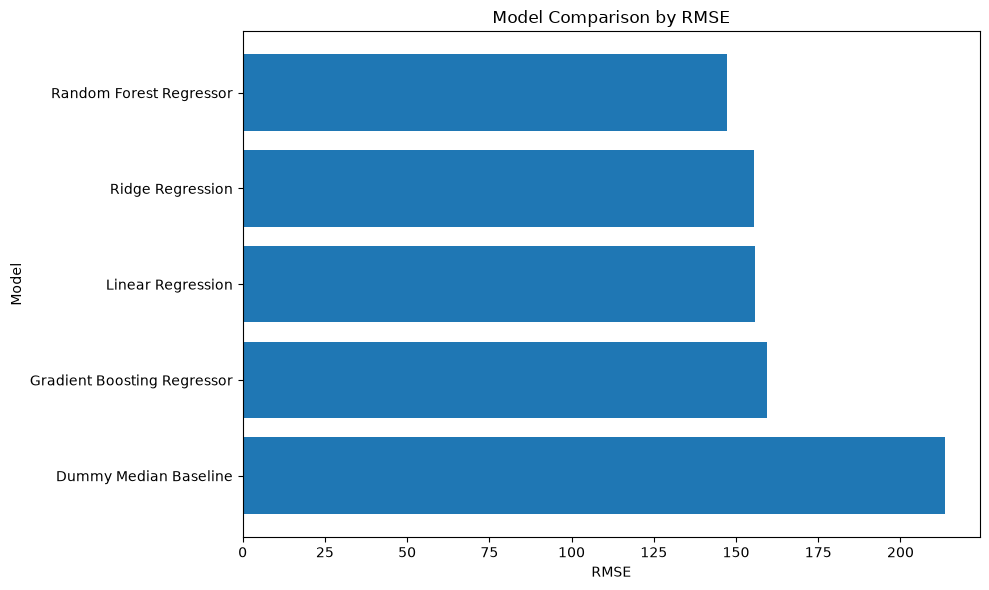

Saved figure to: ..\reports\figures\machine_learning\model_comparison_by_rmse.png


In [45]:
plt.figure(figsize=(10, 6))
plt.barh(
    model_results["model_name"],
    model_results["rmse"]
)
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = ML_FIGURES_PATH / "model_comparison_by_rmse.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Model Performance Interpretation

The baseline model provides a minimum benchmark by predicting the median listing price for every test record.

Machine learning models are evaluated against this baseline using MAE, RMSE, and R².  
A useful model should reduce prediction error compared with the baseline and produce a higher R² score.

Because listing price is highly skewed and contains outliers, RMSE may be strongly affected by high-price listings.  
MAE is also important because it is easier to interpret as the average prediction error.

### Model Performance Interpretation

The Random Forest Regressor produced the best overall performance among the tested models.

It achieved the lowest MAE and RMSE and the highest R² score, outperforming the dummy median baseline by a clear margin.  
This shows that the selected listing, host, review, availability, and neighbourhood features contain useful predictive information for estimating Airbnb listing price.

The model explains around half of the variation in listing price.  
This is reasonable for a first-stage price prediction model because Airbnb prices are influenced by additional factors not fully captured in the dataset, such as property quality, photos, exact location, seasonality, special events, and host pricing strategy.

## 4. Feature Importance Analysis

This section analyzes feature importance from the best-performing model.

Feature importance helps explain which variables contribute most to price prediction.  
The Random Forest Regressor is used because it achieved the best performance among the tested models.

In [46]:
# Get numeric feature names
processed_numeric_feature_names = numeric_features_clean

# Get categorical feature names after one-hot encoding
onehot_encoder = preprocessor.named_transformers_["categorical"].named_steps["onehot"]

processed_categorical_feature_names = onehot_encoder.get_feature_names_out(
    categorical_features_clean
).tolist()

processed_feature_names = (
    processed_numeric_feature_names +
    processed_categorical_feature_names
)

print("Processed feature count:", len(processed_feature_names))
print("Random Forest importance count:", len(random_forest_model.feature_importances_))

Processed feature count: 121
Random Forest importance count: 121


In [47]:
feature_importance_df = pd.DataFrame({
    "feature": processed_feature_names,
    "importance": random_forest_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
)

feature_importance_df.head(20)

,feature,importance
11,bedrooms,0.198268
17,review_scores_value,0.136587
0,minimum_nights,0.076970
12,beds,0.054062
10,bathrooms,0.053572
104,neighbourhood_Centrum-West,0.053147
22,neighbourhood_median_price,0.046080
21,avg_reviews_per_year,0.031586
13,amenities_count,0.028138
2,reviews_per_month,0.023834


In [48]:
feature_importance_output_path = ML_REPORTS_PATH / "random_forest_feature_importance.csv"

feature_importance_df.to_csv(feature_importance_output_path, index=False)

print(f"Feature importance saved to: {feature_importance_output_path}")

Feature importance saved to: ..\reports\machine_learning\random_forest_feature_importance.csv


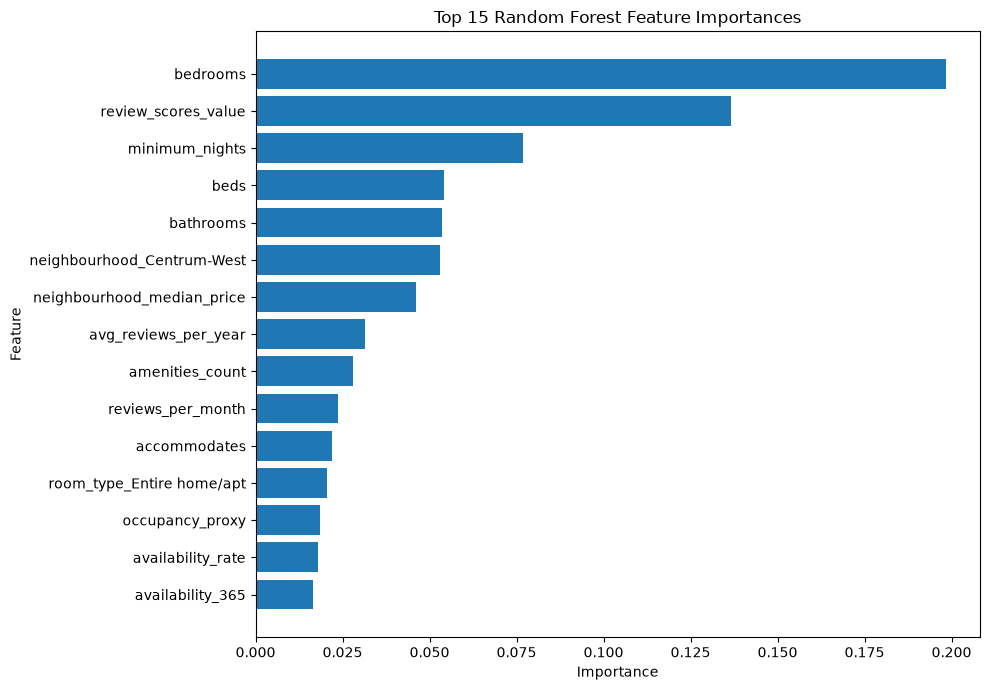

Saved figure to: ..\reports\figures\machine_learning\random_forest_top_feature_importance.png


In [49]:
top_feature_importance = feature_importance_df.head(15).copy()

plt.figure(figsize=(10, 7))
plt.barh(
    top_feature_importance["feature"],
    top_feature_importance["importance"]
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

output_path = ML_FIGURES_PATH / "random_forest_top_feature_importance.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to: {output_path}")

### Feature Importance Interpretation

Feature importance shows which variables contributed most to the Random Forest price prediction model.

The most important features should be interpreted as predictive signals, not causal drivers.  
A high feature importance means the model used that feature often to r
educe prediction error.

Feature importance helps connect the machine learning model back to business understanding by showing whether price is mainly influenced by property size, room type, neighbourhood context, host behavior, review activity, or availability patterns.